Author: Jessica Xu

This code performs Exploratory Data Analysis (EDA) on both Google Places and Yelp datasets, merging them into a single dataframe by identifying and matching overlapping restaurants.

References:
https://scikit-learn.org/stable/modules/neighbors.html

AI used only for debugging and minor modifications.

In [1]:
import os
import numpy as np
import pandas as pd
import jellyfish
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

In [2]:
# load dataset
BASE_DIR = os.getcwd()

GP_FILENAME = "Google_Place_Chicago_restaurants/gp_chicago_clean.csv"
YELP_FILENAME = "Yelp_Chicago_restaurants/yelp_chicago_clean.csv"

GP_FILEPATH = os.path.join(BASE_DIR, GP_FILENAME)
YELP_FILEPATH = os.path.join(BASE_DIR, YELP_FILENAME)

gp = pd.read_csv(GP_FILEPATH)
yelp = pd.read_csv(YELP_FILEPATH)

print("gp rows:", len(gp))
print("yelp rows:", len(yelp))

gp rows: 3388
yelp rows: 5112


In [3]:
# ensure zip as strings
gp["gp_zipcode"] = gp["gp_zipcode"].astype(str).str.extract(r"(\d{5})", expand=False)
yelp["yelp_zip_code"] = yelp["yelp_zip_code"].astype(str).str.extract(r"(\d{5})", expand=False)

# ensure numeric price price level
gp["gp_price_level_1to4"] = pd.to_numeric(gp["gp_price_level_1to4"], errors="coerce")
yelp["yelp_price_level_1to4"] = pd.to_numeric(yelp["yelp_price_level_1to4"], errors="coerce")

##  Exploratory Data Analysis (Google Place)

In [4]:
gp.shape, gp.columns # GP dataset collects 3388 restaurants 

((3388, 36),
 Index(['gp_place_id', 'gp_name', 'gp_address', 'gp_latitude', 'gp_longitude',
        'gp_price_range_raw', 'gp_price_level', 'gp_rating', 'gp_review_count',
        'gp_types', 'gp_primary_type', 'gp_business_status',
        'gp_regular_opening_hours_raw', 'gp_takeout', 'gp_delivery',
        'gp_dine_in', 'gp_reservable', 'gp_query_lat', 'gp_query_lon',
        'gp_specific_address', 'gp_city', 'gp_zipcode', 'gp_country',
        'gp_name_norm', 'gp_price_level_1to4', 'gp_price_start', 'gp_price_end',
        'gp_open_days_per_week', 'gp_total_open_minutes_week',
        'gp_avg_open_minutes_open_day', 'gp_weekend_open_minutes',
        'gp_open_late_minutes', 'gp_takeout_d', 'gp_delivery_d', 'gp_dine_in_d',
        'gp_reservable_d'],
       dtype='object'))

In [5]:
gp.head()

,gp_place_id,gp_name,gp_address,gp_latitude,gp_longitude,gp_price_range_raw,gp_price_level,gp_rating,gp_review_count,gp_types,...,gp_price_end,gp_open_days_per_week,gp_total_open_minutes_week,gp_avg_open_minutes_open_day,gp_weekend_open_minutes,gp_open_late_minutes,gp_takeout_d,gp_delivery_d,gp_dine_in_d,gp_reservable_d
0,ChIJv15g9A0oDogR17kmKKP3L2Y,Southside African Restaurant,"8311 S Baltimore Ave, Chicago, IL 60617, USA",41.744492,-87.555114,"{'startPrice': {'currencyCode': 'USD', 'units'...",PRICE_LEVEL_INEXPENSIVE,4.1,442,"african_restaurant,restaurant,point_of_interes...",...,20.0,6.0,3240.0,540.00,540.0,0.0,1,1,1,1
1,ChIJVzca9BYoDogRbIfKE9xNjaE,Little Caesars Pizza,"7902 S Exchange Ave, Chicago, IL 60617, USA",41.751793,-87.553363,"{'startPrice': {'currencyCode': 'USD', 'units'...",PRICE_LEVEL_INEXPENSIVE,3.6,380,"pizza_restaurant,fast_food_restaurant,meal_del...",...,10.0,7.0,5400.0,771.43,1560.0,360.0,1,1,0,0
2,ChIJQ8_RNBMpDogRNmc9V3D6iC0,Urban Luxe Cafe,"2911 E 79th St, Chicago, IL 60649, USA",41.751705,-87.553591,"{'startPrice': {'currencyCode': 'USD', 'units'...",PRICE_LEVEL_MODERATE,4.8,234,"coffee_shop,ice_cream_shop,comedy_club,vegan_r...",...,20.0,NaN,NaN,NaN,NaN,NaN,1,1,1,0
3,ChIJB27IyRIpDogR1GH_CLBSnqI,Los Tacos & Desserts,"8548 S Commercial Ave, Chicago, IL 60617, USA",41.739610,-87.551729,"{'startPrice': {'currencyCode': 'USD', 'units'...",PRICE_LEVEL_INEXPENSIVE,3.7,372,"mexican_restaurant,restaurant,point_of_interes...",...,20.0,6.0,3780.0,630.00,1260.0,0.0,1,1,1,1
4,ChIJuVSSBQ8oDogRY369He4zM14,El Jacalito,"8465 S Commercial Ave, Chicago, IL 60617, USA",41.741746,-87.551363,"{'startPrice': {'currencyCode': 'USD', 'units'...",PRICE_LEVEL_INEXPENSIVE,4.6,279,"mexican_restaurant,american_restaurant,restaur...",...,20.0,5.0,2100.0,420.00,0.0,0.0,1,0,1,0


In [6]:
# check for missing data
gp.isnull().sum().sort_values(ascending=False)

gp_reservable                   1127
gp_price_end                     729
gp_price_start                   709
gp_price_range_raw               709
gp_price_level_1to4              690
gp_price_level                   690
gp_dine_in                       431
gp_delivery                      431
gp_takeout                       167
gp_regular_opening_hours_raw     122
gp_open_days_per_week            122
gp_total_open_minutes_week       122
gp_avg_open_minutes_open_day     122
gp_weekend_open_minutes          122
gp_open_late_minutes             122
gp_rating                        105
gp_specific_address               27
gp_primary_type                    4
gp_name_norm                       0
gp_takeout_d                       0
gp_delivery_d                      0
gp_dine_in_d                       0
gp_place_id                        0
gp_query_lon                       0
gp_country                         0
gp_zipcode                         0
gp_city                            0
g

In [7]:
gp.dtypes

gp_place_id                      object
gp_name                          object
gp_address                       object
gp_latitude                     float64
gp_longitude                    float64
gp_price_range_raw               object
gp_price_level                   object
gp_rating                       float64
gp_review_count                   int64
gp_types                         object
gp_primary_type                  object
gp_business_status               object
gp_regular_opening_hours_raw     object
gp_takeout                       object
gp_delivery                      object
gp_dine_in                       object
gp_reservable                    object
gp_query_lat                    float64
gp_query_lon                    float64
gp_specific_address              object
gp_city                          object
gp_zipcode                       object
gp_country                       object
gp_name_norm                     object
gp_price_level_1to4             float64


In [8]:
# check restaurant uniqueness
print("unique gp_place_id:", gp["gp_place_id"].nunique())
print("duplicate gp_place_id:", gp["gp_place_id"].duplicated().sum())

unique gp_place_id: 3388
duplicate gp_place_id: 0


In [9]:
# check descriptive stats
gp[["gp_rating", "gp_review_count", "gp_price_level_1to4","gp_latitude", "gp_longitude"]].apply(pd.to_numeric, errors="coerce").describe().T

,count,mean,std,min,25%,50%,75%,max
gp_rating,3283.0,4.150168,0.549507,1.000000,3.800000,4.300000,4.500000,5.000000
gp_review_count,3388.0,894.862751,1501.651011,0.000000,162.750000,485.500000,1083.500000,24852.000000
gp_price_level_1to4,2698.0,1.494440,0.564825,1.000000,1.000000,1.000000,2.000000,4.000000
gp_latitude,3388.0,41.858960,0.090238,41.650128,41.780512,41.868866,41.936031,42.021538
gp_longitude,3388.0,-87.687255,0.066538,-87.910656,-87.726143,-87.683153,-87.643229,-87.525281


In [10]:
# price distribution
display(gp["gp_price_level_1to4"].value_counts(dropna=False).sort_index())

gp_price_level_1to4
1.0    1443
2.0    1190
3.0      51
4.0      14
NaN     690
Name: count, dtype: int64

Google Places shows a heavier concentration of low price levels (1–2). The price_level field is also frequently missing, which may make higher price categories appear rarer than they truly are. In addition, the grid-based sampling may over-represent dense areas with many low/mid-priced restaurants, so we treat price_level as a noisy measure and report its distribution and missing rate as a limitation.

In [11]:
# count number of restaurants by zipcode
display(gp["gp_zipcode"].value_counts(dropna=False).head(15))

gp_zipcode
60632    134
60608    133
60639    126
60617    120
60620    112
60609    107
60629    107
60647    106
60619    104
60618    103
60638    100
60634     95
60628     91
60616     84
60623     81
Name: count, dtype: int64

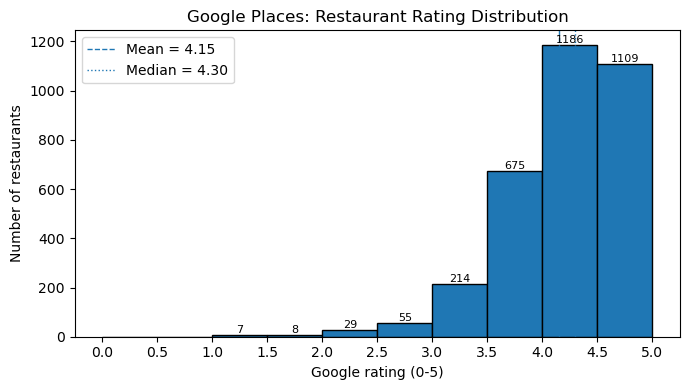

In [12]:
# take a look at rating distribution
gp_r = gp["gp_rating"].dropna()

bins = np.arange(0, 5.5, 0.5)
plt.figure(figsize=(7, 4))

counts, bin_edges, patches = plt.hist(gp_r, bins=bins, edgecolor="black")

for c, p in zip(counts, patches):
    if c > 0:
        x = p.get_x() + p.get_width()/2
        y = p.get_height()
        plt.text(x, y, f"{int(c)}", ha="center", va="bottom", fontsize=8)

plt.axvline(gp_r.mean(), linestyle="--", linewidth=1, label=f"Mean = {gp_r.mean():.2f}")
plt.axvline(gp_r.median(), linestyle=":", linewidth=1, label=f"Median = {gp_r.median():.2f}")

plt.title("Google Places: Restaurant Rating Distribution")
plt.xlabel("Google rating (0-5)")
plt.ylabel("Number of restaurants")
plt.xticks(np.arange(0, 5.5, 0.5))
plt.legend()
plt.tight_layout()
plt.show()

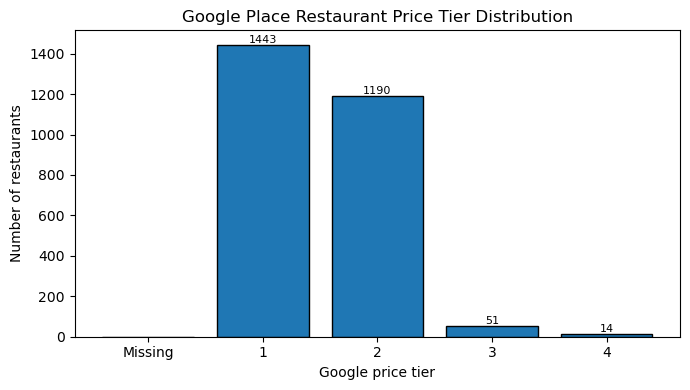

In [13]:
# take a look at price level distribution
col = "gp_price_level_1to4"

tiers = pd.to_numeric(gp[col], errors="coerce")
counts = tiers.value_counts(dropna=False).to_dict()

x_labels = ["Missing", "1", "2", "3", "4"] # convert to numeric
y_vals = [
    int(counts.get(np.nan, 0)),
    int(counts.get(1.0, 0)),
    int(counts.get(2.0, 0)),
    int(counts.get(3.0, 0)),
    int(counts.get(4.0, 0)),
]

plt.figure(figsize=(7, 4))
bars = plt.bar(x_labels, y_vals, edgecolor="black")

for b in bars:
    h = b.get_height()
    if h > 0:
        plt.text(b.get_x() + b.get_width()/2, h, f"{int(h)}",
                 ha="center", va="bottom", fontsize=8)

plt.title("Google Place Restaurant Price Tier Distribution")
plt.xlabel("Google price tier")
plt.ylabel("Number of restaurants")
plt.tight_layout()
plt.show()

##  Exploratory Data Analysis (Yelp)

In [14]:
yelp.head()

,yelp_business_id,yelp_name,yelp_display_address,yelp_address1,yelp_zip_code,yelp_city,yelp_state,yelp_latitude,yelp_longitude,yelp_price,yelp_rating,yelp_review_count,yelp_is_closed,yelp_transactions,yelp_categories,yelp_name_norm,yelp_price_level_1to4,yelp_delivery_d,yelp_pickup_d,yelp_restaurant_reservation_d
0,ZR4huVV1jdOM8psH3kNaCw,The Foxtail on the Lake,"1177 Howard Ave Des Plaines, IL 60018",1177 Howard Ave,60018,Des Plaines,IL,42.015693,-87.896417,$$$,4.3,522,False,NaN,"Seafood,Mediterranean,Cocktail Bars",the foxtail on the lake,3.0,0,0,0
1,0k018u1PAtfmkNRYk04yCQ,Tortas Frontera,10000 W O'Hare Ave Terminal 1 - Gate B11 Chica...,10000 W O'Hare Ave,60666,Chicago,IL,41.980026,-87.906679,$$,3.9,1484,False,NaN,Mexican,tortas frontera,2.0,0,0,0
2,1zZvM7Zy__Oh533E4bt6_A,Tortas Frontera,Terminal 3 - Gate K4 10000 W O'Hare Ave Termin...,Terminal 3 - Gate K4,60666,Chicago,IL,41.975438,-87.900137,$$,3.7,1572,False,NaN,Mexican,tortas frontera,2.0,0,0,0
3,Kqw7fZjGvtvIl1k_kMK1Yw,Chicago Ramen,"578 E Oakton St Des Plaines, IL 60018",578 E Oakton St,60018,Des Plaines,IL,42.023596,-87.909561,$$,4.3,493,False,"delivery,pickup",Ramen,chicago ramen,2.0,1,1,0
4,bXn9pytB9EPoTawqx-RNrg,Berghoff Cafe,"10000 W O'Hare Terminal 1, Concourse C, Gate 2...",10000 W O'Hare,60666,Chicago,IL,41.980586,-87.909963,$$,3.5,402,False,NaN,German,berghoff cafe,2.0,0,0,0


In [15]:
yelp.isnull().sum().sort_values(ascending=False)

yelp_price_level_1to4            2053
yelp_price                       2053
yelp_transactions                1211
yelp_address1                      65
yelp_categories                     1
yelp_business_id                    0
yelp_review_count                   0
yelp_pickup_d                       0
yelp_delivery_d                     0
yelp_name_norm                      0
yelp_is_closed                      0
yelp_rating                         0
yelp_name                           0
yelp_longitude                      0
yelp_latitude                       0
yelp_state                          0
yelp_city                           0
yelp_zip_code                       0
yelp_display_address                0
yelp_restaurant_reservation_d       0
dtype: int64

In [16]:
yelp.shape, yelp.columns # Yelp dataset collects 5112 restaurants 

((5112, 20),
 Index(['yelp_business_id', 'yelp_name', 'yelp_display_address',
        'yelp_address1', 'yelp_zip_code', 'yelp_city', 'yelp_state',
        'yelp_latitude', 'yelp_longitude', 'yelp_price', 'yelp_rating',
        'yelp_review_count', 'yelp_is_closed', 'yelp_transactions',
        'yelp_categories', 'yelp_name_norm', 'yelp_price_level_1to4',
        'yelp_delivery_d', 'yelp_pickup_d', 'yelp_restaurant_reservation_d'],
       dtype='object'))

In [17]:
yelp.dtypes

yelp_business_id                  object
yelp_name                         object
yelp_display_address              object
yelp_address1                     object
yelp_zip_code                     object
yelp_city                         object
yelp_state                        object
yelp_latitude                    float64
yelp_longitude                   float64
yelp_price                        object
yelp_rating                      float64
yelp_review_count                  int64
yelp_is_closed                      bool
yelp_transactions                 object
yelp_categories                   object
yelp_name_norm                    object
yelp_price_level_1to4            float64
yelp_delivery_d                    int64
yelp_pickup_d                      int64
yelp_restaurant_reservation_d      int64
dtype: object

In [18]:
# check restaurant uniqueness
print("unique yelp_business_id:", yelp["yelp_business_id"].nunique())
print("duplicate yelp_business_id:", yelp["yelp_business_id"].duplicated().sum())

unique yelp_business_id: 5112
duplicate yelp_business_id: 0


In [19]:
# check descriptive stats
yelp[["yelp_rating", "yelp_review_count", "yelp_price_level_1to4", "yelp_latitude", "yelp_longitude"]].apply(pd.to_numeric, errors="coerce").describe().T

,count,mean,std,min,25%,50%,75%,max
yelp_rating,5112.0,3.538067,1.240342,0.000000,3.200000,3.900000,4.300000,5.000000
yelp_review_count,5112.0,235.671166,555.324964,0.000000,13.000000,64.000000,238.250000,10625.000000
yelp_price_level_1to4,3059.0,1.742073,0.651881,1.000000,1.000000,2.000000,2.000000,4.000000
yelp_latitude,5112.0,41.878524,0.089328,41.324092,41.810415,41.889043,41.944627,42.041091
yelp_longitude,5112.0,-87.682742,0.070720,-87.941675,-87.712787,-87.668642,-87.632149,-87.526177


In [20]:
# price distribution 
display(yelp["yelp_price_level_1to4"].value_counts(dropna=False).sort_index())

yelp_price_level_1to4
1.0    1096
2.0    1706
3.0     207
4.0      50
NaN    2053
Name: count, dtype: int64

In [21]:
# count number of restaurants by zipcode
display(yelp["yelp_zip_code"].value_counts(dropna=False).head(15))

yelp_zip_code
60611    205
60618    188
60622    176
60657    165
60608    140
60647    129
60607    129
60659    124
60616    118
60612    115
60018    113
60666    109
60654    108
60629    104
60614    103
Name: count, dtype: int64

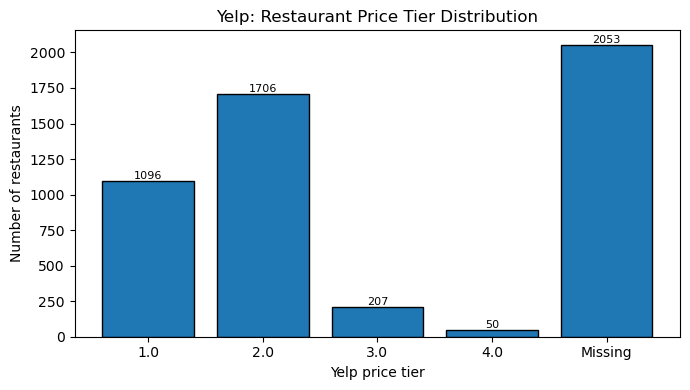

In [22]:
# take a look at Yelp price level distribution
price_counts = (yelp["yelp_price_level_1to4"].fillna("Missing").astype(str).value_counts().sort_index())

plt.figure(figsize=(7, 4))
bars = plt.bar(price_counts.index, price_counts.values, edgecolor="black")

for b in bars:
    h = b.get_height()
    if h > 0:
        plt.text(
            b.get_x() + b.get_width() / 2,
            h,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.title("Yelp: Restaurant Price Tier Distribution")
plt.xlabel("Yelp price tier")
plt.ylabel("Number of restaurants")
plt.tight_layout()
plt.show()

## Merge data

In [23]:
# blocking
max_dist_m = 200
use_zip_block = True

gp_id_col = "gp_place_id"
gp_lat_col = "gp_latitude"
gp_lon_col = "gp_longitude"
gp_zip_col = "gp_zipcode"

yelp_id_col = "yelp_business_id"
yelp_lat_col = "yelp_latitude"
yelp_lon_col = "yelp_longitude"
yelp_zip_col = "yelp_zip_code"

# drop missing
gp_block = gp.dropna(subset=[gp_lat_col, gp_lon_col]).copy()
yelp_block = yelp.dropna(subset=[yelp_lat_col, yelp_lon_col]).copy()

# set balltree radians
gp_coords = np.deg2rad(gp_block[[gp_lat_col, gp_lon_col]].to_numpy())
yelp_coords = np.deg2rad(yelp_block[[yelp_lat_col, yelp_lon_col]].to_numpy())

tree = BallTree(yelp_coords, metric="haversine")

# convert meter to radians
radius_rad = max_dist_m / 6_371_000

# find candidates within radius
idx_lists, dist_lists = tree.query_radius(gp_coords, r=radius_rad, return_distance=True)

candidate_rows = []
for i, (idxs, dists) in enumerate(zip(idx_lists, dist_lists)):
    if len(idxs) == 0:
        continue

    gp_row = gp_block.iloc[i]
    current_gp_id = gp_row[gp_id_col]

    gp_zip = str(gp_row.get(gp_zip_col, "")).strip()
    gp_zip_ok = gp_zip and gp_zip.lower() != "nan"

    for j, dist_rad in zip(idxs, dists):
        yelp_row = yelp_block.iloc[j]

        if use_zip_block and gp_zip_ok:
            yelp_zip = str(yelp_row.get(yelp_zip_col, "")).strip()
            if yelp_zip and yelp_zip != gp_zip:
                continue

        candidate_rows.append({
            gp_id_col: current_gp_id,
            yelp_id_col: yelp_row[yelp_id_col],
            "dist_m": float(dist_rad * 6_371_000),
        })

candidates = pd.DataFrame(candidate_rows)

print("blocking candidates rows:", len(candidates))
print("gp with >=1 candidate:", candidates[gp_id_col].nunique())
candidates.head()

blocking candidates rows: 15020
gp with >=1 candidate: 3021


,gp_place_id,yelp_business_id,dist_m
0,ChIJv15g9A0oDogR17kmKKP3L2Y,ZTc65Wcj89EUuC7z2lixZA,50.052870
1,ChIJVzca9BYoDogRbIfKE9xNjaE,Ya0Sf9cYp_o1A5s9v-9pLA,21.681611
2,ChIJVzca9BYoDogRbIfKE9xNjaE,sYmU0tupbVsm1rzBQzMANg,35.184222
3,ChIJVzca9BYoDogRbIfKE9xNjaE,usp4FP8luWLBekVH4OOJPA,32.357817
4,ChIJQ8_RNBMpDogRNmc9V3D6iC0,XZfUHf516Zg2x89Fwjoqaw,1.220577


In [24]:
cand = candidates.merge(
    gp[["gp_place_id", "gp_name_norm", "gp_specific_address", "gp_zipcode"]],
    on="gp_place_id",
    how="left"
).merge(
    yelp[["yelp_business_id", "yelp_name_norm", "yelp_address1", "yelp_zip_code"]],
    on="yelp_business_id",
    how="left"
)

# set similarity
def jw_100(a, b):
    a = "" if pd.isna(a) else str(a)
    b = "" if pd.isna(b) else str(b)
    return 100 * jellyfish.jaro_winkler_similarity(a, b)

def lev_sim_100(a, b):
    a = "" if pd.isna(a) else str(a)
    b = "" if pd.isna(b) else str(b)
    if len(a) == 0 and len(b) == 0:
        return 100.0
    d = jellyfish.levenshtein_distance(a, b)
    return 100 * (1 - d / max(len(a), len(b)))

cand["name_sim"] = cand.apply(lambda r: jw_100(r["gp_name_norm"], r["yelp_name_norm"]), axis=1)
cand["addr_sim"] = cand.apply(lambda r: lev_sim_100(r["gp_specific_address"], r["yelp_address1"]), axis=1)

# cal distance score
MAX_DIST_M = 200
cand["dist_score"] = 100 * (1 - (cand["dist_m"] / MAX_DIST_M)).clip(lower=0, upper=1)

# cal overall match score
cand["score"] = 0.60 * cand["name_sim"] + 0.30 * cand["addr_sim"] + 0.10 * cand["dist_score"]

# pick best matched Yelp for each GP 
best = (
    cand.sort_values(["gp_place_id", "score", "dist_m"], ascending=[True, False, True])
        .groupby("gp_place_id", as_index=False)
        .first()
)

# apply threshold
final_match = best[(best["score"] >= 88) & (best["dist_m"] <= MAX_DIST_M)].copy()
final_match = (final_match.sort_values("score", ascending=False).drop_duplicates(subset="yelp_business_id"))

print("Final matched GP:", final_match["gp_place_id"].nunique())
print("Final matched Yelp:", final_match["yelp_business_id"].nunique())
final_match.head()

Final matched GP: 1850
Final matched Yelp: 1850


,gp_place_id,yelp_business_id,dist_m,gp_name_norm,gp_specific_address,gp_zipcode,yelp_name_norm,yelp_address1,yelp_zip_code,name_sim,addr_sim,dist_score,score
2224,ChIJja3R4OEtDogRrc5n8J9LTE0,PFAg72nWgzNzfs9r7BR-FQ,0.0,raising cane s chicken fingers,2 N Michigan Ave,60602,raising cane s chicken fingers,2 N Michigan Ave,60602,100.0,100.0,100.0,100.0
2049,ChIJfd-z_P4tDogRV7147ELK0ns,5CPMzmua1XTEb-xI9os8ig,0.0,falco s pizza,2806 W 40th Pl,60632,falco s pizza,2806 W 40th Pl,60632,100.0,100.0,100.0,100.0
2854,ChIJwb3X2rLTD4gRl5-rajcHWzw,1idYafjrRj4GsMhzLExuCw,0.0,the bakehouse chicago,3915 N Sheridan Rd,60613,the bakehouse chicago,3915 N Sheridan Rd,60613,100.0,100.0,100.0,100.0
2829,ChIJw03pYWYtDogRD5w6F7LhzFo,uQ8fHNvR5OpT_rtLhCxlrA,0.0,chipotle mexican grill,3125 S Ashland Ave,60608,chipotle mexican grill,3125 S Ashland Ave,60608,100.0,100.0,100.0,100.0
186,ChIJ2frCB0gvDogRXA7tF8yFtiU,WNiybL5YoT6kAsmXFkKX2Q,0.0,fh jerkgod,111 E 51st St,60615,fh jerkgod,111 E 51st St,60615,100.0,100.0,100.0,100.0


In [25]:
# check matches with lowest score, which seems fine
final_match.sort_values("score", ascending=True).head(5)[["gp_name_norm", "yelp_name_norm", "gp_specific_address", "yelp_address1", "score", "dist_m"]]

,gp_name_norm,yelp_name_norm,gp_specific_address,yelp_address1,score,dist_m
1242,dino s italian pizza and italian restaurant,dino s pizza,7004 W Higgins Ave,7004 W Higgins Ave,88.039864,26.179457
312,los cuates de juanita s,los cuates de juanita,2757 W 71st St #2759,2759 W 71st St,88.134962,6.431193
2601,mcdonald s 37872,mcdonalds,2315 W Ogden Ave,2315 Ogden Ave,88.177009,56.459816
810,fatpour mccormick ultimate chicago sports bar,fatpour tap works mccormick,2206 S Indiana Ave,2206 S Indiana Ave,88.249633,26.340666
2085,wicker park seafood and sushi bar,wicker park sushi,10000 W O'Hare Ave,10000 W O'Hare Ave,88.282231,103.874097


In [26]:
# Merge full GP + full Yelp info onto final_match
matched_all = (final_match.merge(gp, on="gp_place_id", how="left").merge(yelp, on="yelp_business_id", how="left"))

print("Rows:", len(matched_all))
print("Unique GP:", matched_all["gp_place_id"].nunique())
print("Unique Yelp:", matched_all["yelp_business_id"].nunique())

Rows: 1850
Unique GP: 1850
Unique Yelp: 1850


In [27]:
matched_all.to_csv("gp_yelp_matched.csv", index=False)

## Clean matched dataset

In [28]:
# load matched dataset

FILENAME = "gp_yelp_matched.csv"
FILEPATH = os.path.join(BASE_DIR, FILENAME)
gp_yelp_matched = pd.read_csv(FILEPATH)

print("rows:", len(gp_yelp_matched))

rows: 1850


In [29]:
# make a copy for cleaned output
gp_yelp_matched_cleaned = gp_yelp_matched.copy()


In [30]:
# convert features to numeric types so that missing values are represented as NaN
gp_rating = pd.to_numeric(gp_yelp_matched_cleaned["gp_rating"], errors="coerce")
yelp_rating = pd.to_numeric(gp_yelp_matched_cleaned["yelp_rating"], errors="coerce")
gp_rc = pd.to_numeric(gp_yelp_matched_cleaned["gp_review_count"], errors="coerce")
yelp_rc = pd.to_numeric(gp_yelp_matched_cleaned["yelp_review_count"], errors="coerce")
gp_price = pd.to_numeric(gp_yelp_matched_cleaned["gp_price_level_1to4"], errors="coerce")
yelp_price = pd.to_numeric(gp_yelp_matched_cleaned["yelp_price_level_1to4"], errors="coerce")

In [31]:
# Create res_rating by merging Google and Yelp ratings into a single value
# If both ratings are available and at least one review count is non-missing, a review-count-weighted average is used
# If only one rating is available (or both review counts are missing/zero), get a mean across ratings
# If both ratings are missing, res_rating remains NaN
w_sum = gp_rc.fillna(0) + yelp_rc.fillna(0)
weighted_rating = (gp_rating * gp_rc.fillna(0) + yelp_rating * yelp_rc.fillna(0)) / w_sum.replace(0, np.nan)
avg_rating = pd.concat([gp_rating, yelp_rating], axis=1).mean(axis=1, skipna=True)
use_weighted = gp_rating.notna() & yelp_rating.notna() & (w_sum > 0)
gp_yelp_matched_cleaned["res_rating"] = np.where(use_weighted, weighted_rating, avg_rating)

In [32]:
# Create res_review_count by combining review counts from both platforms
# If both review counts are available, the values are added together to show total reviews across platforms
# If only one review count is available, that value is used
# If both review counts are missing, res_review_count remains NaN
gp_yelp_matched_cleaned["res_review_count"] = np.where(gp_rc.notna() & yelp_rc.notna(), gp_rc + yelp_rc, np.where(gp_rc.notna(), gp_rc, yelp_rc))

In [33]:
# Create res_takeout by carrying over Google’s takeout value (0/1)
gp_yelp_matched_cleaned["res_takeout"] = pd.to_numeric(gp_yelp_matched_cleaned["gp_takeout_d"], errors="coerce")

In [34]:
# Create res_delivery as a delivery indicator across platforms
# If either Google delivery or Yelp delivery is 1, res_delivery = 1; otherwise = 0
gp_del = pd.to_numeric(gp_yelp_matched_cleaned["gp_delivery_d"], errors="coerce").fillna(0).astype(int)
yelp_del = pd.to_numeric(gp_yelp_matched_cleaned["yelp_delivery_d"], errors="coerce").fillna(0).astype(int)
gp_yelp_matched_cleaned["res_delivery"] = ((gp_del == 1) | (yelp_del == 1)).astype(int)

In [35]:
# Create res_dine_in by carrying over Google’s dine-in indicator (0/1)
gp_yelp_matched_cleaned["res_dine_in"] = pd.to_numeric(gp_yelp_matched_cleaned["gp_dine_in_d"], errors="coerce")

In [36]:
# Create res_reservable as a reservation indicator across platforms
# If either Google reservable or Yelp restaurant reservation is 1, res_reservable =1; otherwise=0
gp_res = pd.to_numeric(gp_yelp_matched_cleaned["gp_reservable_d"], errors="coerce").fillna(0).astype(int)
yelp_res = pd.to_numeric(gp_yelp_matched_cleaned["yelp_restaurant_reservation_d"], errors="coerce").fillna(0).astype(int)
gp_yelp_matched_cleaned["res_reservable"] = ((gp_res == 1) | (yelp_res == 1)).astype(int)

In [37]:
# Create res_pickup by carrying over Yelp’s pickup indicator (0/1)
gp_yelp_matched_cleaned["res_pickup"] = pd.to_numeric(gp_yelp_matched_cleaned["yelp_pickup_d"], errors="coerce")

Note: Google Places and Yelp use very similar four-tier price classifications, with only minor differences in their exact dollar cutoffs. On Yelp, one dollar sign represents under $10, two dollar signs roughly $11–30, three dollar signs $31–60, and four dollar signs above $61, while Google defines one dollar sign as $10 and under, two dollar signs roughly $10–25, three dollar signs $25–45, and four dollar signs $50 and up. Although the precise boundaries differ slightly, both systems categorize restaurants into comparable low, moderate, high, and very high price tiers, making it reasonable to merge them into a 1–4 ordinal price measure for analysis.

In [38]:
# Create res_price_level by merging Google and Yelp price tiers (1–4) into a single value
# If both price tiers are available, the higher tier is used so the merged price level never downshifts
# If only one platform reports price, that value is used
# If neither platform reports price, res_price_level remains NaN

gp_yelp_matched_cleaned["res_price_level"] = pd.concat([gp_price, yelp_price], axis=1).max(axis=1, skipna=True)

In [39]:
gp_yelp_matched_cleaned.to_csv("gp_yelp_matched_cleaned.csv", index=False)